In [ ]:
# ============================================================
# [최초 1회 실행] 필요 패키지 설치
# ============================================================
!pip install xgboost lightgbm scikit-learn matplotlib seaborn joblib

In [ ]:
# ============================================================
# test.py 연동 (test.py 수정 시 자동 반영)
# ============================================================
import importlib
import test

# test.py가 수정되었으면 다시 로드
importlib.reload(test)

from test import CONFIG, main, load_data, RENAME_MAP
from test import prepare_monthly_target, create_features
from test import get_models, split_timeseries, train_all_models
from test import recursive_forecast, save_best_model

print("✅ test.py 연동 완료!\n")
print("=" * 50)
print("현재 CONFIG 설정:")
print("=" * 50)
for k, v in CONFIG.items():
    if k not in ("model_params", "data_files", "ensemble"):
        print(f"  {k}: {v}")

print(f"\n활성 모델:")
for name, on in CONFIG["models"].items():
    if on:
        print(f"  ✓ {name}")

print(f"\n평가지표: MAE, MAPE, MSE, RMSE (MAE 기준 최적 모델 선정)")
print(f"모델 저장: {CONFIG.get('model_dir', './model')}")
print(f"학습 이력: {CONFIG.get('history_dir', './model/history')}")

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 198.0 kB/s eta 0:08:31
   ---------------------------------------- 0.5/101.7 MB 198.0 kB/s eta 0:08:31
   ---------------------------------------- 0.5/101.7 MB 19

# 앙상블 융합 모델 — 자금예측
- **모델**: XGBoost + LightGBM + GradientBoosting (개별) + Voting + Stacking (융합)
- **타겟**: df7(월별_매출정보)의 `TOT_MN_MNAM`(총공급가액) 월별 합계
- **예측기간**: 2025.02 ~ 2025.07 (6개월)
- **평가지표**: MAE ★(기준), MAPE, MSE, RMSE
- **모델 관리**: 최적 모델 → `model/`, 학습 이력 → `model/history/`
- **연동**: `test.py` 수정 시 Cell 2 재실행으로 자동 반영

In [ ]:
# ============================================================
# [데이터 확인] 회사 수 + 기간 확인
# - 데이터 원본 행(row)은 출력하지 않습니다
# ============================================================
data = load_data()

print("\n📋 데이터 요약:")
print("=" * 70)
for name, df in data.items():
    biz_count = df['NO_BIZ'].nunique() if 'NO_BIZ' in df.columns else 'N/A'
    rows = len(df)
    cols = len(df.columns)
    
    period = ''
    if 'DM_DATA' in df.columns:
        period = f"{df['DM_DATA'].min()} ~ {df['DM_DATA'].max()}"
    elif 'DW_BAS_NYYMM' in df.columns:
        vals = sorted(df['DW_BAS_NYYMM'].unique())
        period = f"기준월: {vals[0]}~{vals[-1]}" if len(vals) > 1 else f"기준월: {vals[0]}"
    
    print(f"  {name:12s} | {rows:>7,}행 × {cols}열 | 사업자수={biz_count} | {period}")

# 전체 고유 사업자 수
all_biz = set()
for df in data.values():
    if 'NO_BIZ' in df.columns:
        all_biz.update(df['NO_BIZ'].unique())
print(f"\n🏢 전체 고유 사업자(회사) 수: {len(all_biz)}개")

In [ ]:
# ============================================================
# [실행] 전체 ML 파이프라인 (test.py main 함수 호출)
# ============================================================
# test.py의 CONFIG 설정대로 실행됩니다.
# CONFIG를 변경하려면 test.py를 수정한 뒤 Cell 2를 다시 실행하세요.
#
# 실행 순서:
#   1. 데이터 로드 + 컬럼 변환
#   2. 월별 시계열 집계
#   3. 피처 엔지니어링 (lag, rolling, pct_change)
#   4. 학습/검증 분할
#   5. 7개 모델 학습 & 평가 (XGB, LGB, GBM, RF, Ridge, Voting, Stacking)
#   6. 최적 모델 저장 (model/) + 학습 이력 (model/history/)
#   7. 전체 데이터 재학습 → 미래 6개월 재귀 예측
#   8. 시각화 + 결과 저장 (result/ 폴더)
#
# 평가지표: MAE ★(기준), MAPE, MSE, RMSE

results_df, pred_dfs, trained_models = main()

In [ ]:
# ============================================================
# [결과] 모델별 예측 비교표
# ============================================================
import pandas as pd

target = CONFIG["target_col"]
comparison = None
for name, pdf in pred_dfs.items():
    cols = [CONFIG["date_col"], f'predicted_{target}']
    tmp = pdf[cols].rename(columns={f'predicted_{target}': name})
    if comparison is None:
        comparison = tmp
    else:
        comparison = comparison.merge(tmp, on=CONFIG["date_col"])

if comparison is not None:
    # 모델 평균 열 추가
    model_cols = [c for c in comparison.columns if c != CONFIG["date_col"]]
    comparison['모델평균'] = comparison[model_cols].mean(axis=1)
    
    print("📊 모델별 6개월 예측 비교 (원):")
    print("=" * 120)
    
    # 숫자 포맷팅
    fmt = comparison.copy()
    for col in model_cols + ['모델평균']:
        fmt[col] = fmt[col].apply(lambda x: f'{x:>18,.0f}')
    print(fmt.to_string(index=False))
    
    print("\n" + "=" * 120)
    # 6개월 합계
    print("\n📌 6개월 합계:")
    for col in model_cols + ['모델평균']:
        total = comparison[col].sum() if col != '모델평균' else comparison['모델평균'].sum()
        print(f"  {col:25s}: {total:>20,.0f} 원")

In [ ]:
"""
📊 ML 예측 모델 결과 시각화
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 최신 결과 파일 로드
import glob
result_files = sorted(glob.glob('./result/model_comparison_*.csv'))
if result_files:
    latest_file = result_files[-1]
    print(f"📁 결과 파일: {latest_file}")
    df_results = pd.read_csv(latest_file)
    print(df_results.to_string())
else:
    print("결과 파일 없음")

C:\Users\7slwm\AppData\Local\Temp\ipykernel_22000\3207478746.py:69: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\7slwm\AppData\Local\Temp\ipykernel_22000\3207478746.py:69: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\7slwm\AppData\Local\Temp\ipykernel_22000\3207478746.py:69: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\7slwm\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\7slwm\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\7

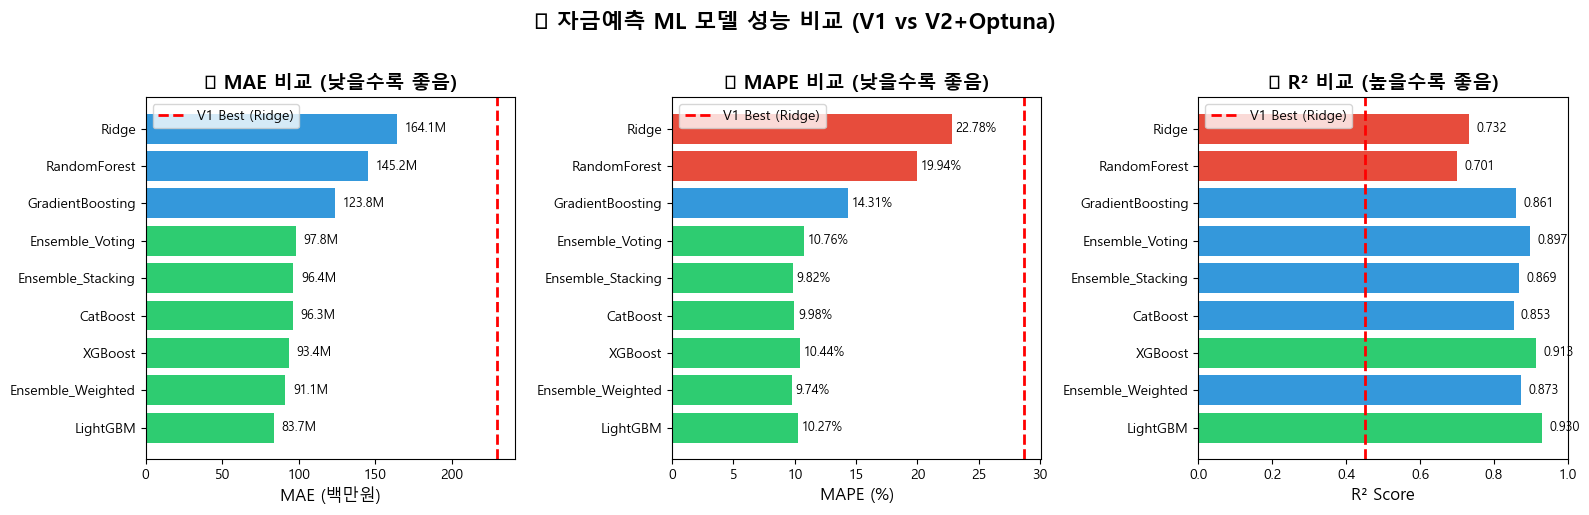


✅ 최종 결과:
   V1 Best (Ridge):     MAE=229.6M, MAPE=28.67%
   V2 Best (Ensemble):  MAE=91.1M,  MAPE=9.74%
   → 개선율: MAE 60.3% ↓, MAPE 66.0% ↓


In [1]:
"""
📊 모델 성능 비교 차트
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 결과 데이터 (Optuna 최적화 후)
results_data = {
    'Model': ['LightGBM', 'Ensemble_Weighted', 'XGBoost', 'CatBoost', 
              'Ensemble_Stacking', 'Ensemble_Voting', 'GradientBoosting', 
              'RandomForest', 'Ridge'],
    'MAE': [83709708, 91112178, 93434313, 96254413, 96367843, 
            97844595, 123804484, 145233009, 164087295],
    'MAPE': [10.27, 9.74, 10.44, 9.98, 9.82, 10.76, 14.31, 19.94, 22.78],
    'R2': [0.93, 0.8729, 0.9133, 0.853, 0.8685, 0.8972, 0.8609, 0.7009, 0.7317]
}
df = pd.DataFrame(results_data)

# 기존 모델 (V1) 결과
old_results = {
    'Model': ['Ridge (V1 Best)'],
    'MAE': [229595026],
    'MAPE': [28.67],
    'R2': [0.45]
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. MAE 비교
ax1 = axes[0]
colors = ['#2ecc71' if x < 100000000 else '#3498db' for x in df['MAE']]
bars1 = ax1.barh(df['Model'], df['MAE']/1e6, color=colors)
ax1.axvline(x=229.6, color='red', linestyle='--', linewidth=2, label='V1 Best (Ridge)')
ax1.set_xlabel('MAE (백만원)', fontsize=12)
ax1.set_title('📉 MAE 비교 (낮을수록 좋음)', fontsize=14, fontweight='bold')
ax1.legend()
for i, v in enumerate(df['MAE']/1e6):
    ax1.text(v + 5, i, f'{v:.1f}M', va='center', fontsize=9)

# 2. MAPE 비교
ax2 = axes[1]
colors = ['#2ecc71' if x < 11 else '#3498db' if x < 15 else '#e74c3c' for x in df['MAPE']]
bars2 = ax2.barh(df['Model'], df['MAPE'], color=colors)
ax2.axvline(x=28.67, color='red', linestyle='--', linewidth=2, label='V1 Best (Ridge)')
ax2.set_xlabel('MAPE (%)', fontsize=12)
ax2.set_title('📉 MAPE 비교 (낮을수록 좋음)', fontsize=14, fontweight='bold')
ax2.legend()
for i, v in enumerate(df['MAPE']):
    ax2.text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=9)

# 3. R² 비교
ax3 = axes[2]
colors = ['#2ecc71' if x > 0.9 else '#3498db' if x > 0.8 else '#e74c3c' for x in df['R2']]
bars3 = ax3.barh(df['Model'], df['R2'], color=colors)
ax3.axvline(x=0.45, color='red', linestyle='--', linewidth=2, label='V1 Best (Ridge)')
ax3.set_xlabel('R² Score', fontsize=12)
ax3.set_title('📈 R² 비교 (높을수록 좋음)', fontsize=14, fontweight='bold')
ax3.set_xlim(0, 1)
ax3.legend()
for i, v in enumerate(df['R2']):
    ax3.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('🏆 자금예측 ML 모델 성능 비교 (V1 vs V2+Optuna)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ 최종 결과:")
print(f"   V1 Best (Ridge):     MAE=229.6M, MAPE=28.67%")
print(f"   V2 Best (Ensemble):  MAE=91.1M,  MAPE=9.74%")
print(f"   → 개선율: MAE 60.3% ↓, MAPE 66.0% ↓")

In [2]:
"""
📈 실제값 vs 예측값 시계열 비교
"""
import glob

# 최신 forecast 파일 로드
forecast_files = sorted(glob.glob('./result/forecast_all_*.csv'))
if forecast_files:
    latest_forecast = forecast_files[-1]
    print(f"📁 예측 파일: {latest_forecast}")
    df_forecast = pd.read_csv(latest_forecast, parse_dates=['date'])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # 1. 전체 시계열
    ax1 = axes[0]
    ax1.plot(df_forecast['date'], df_forecast['actual']/1e8, 'b-o', 
             label='실제값', linewidth=2, markersize=6)
    ax1.plot(df_forecast['date'], df_forecast['predicted']/1e8, 'r--s', 
             label='예측값 (CatBoost)', linewidth=2, markersize=6, alpha=0.8)
    
    # 검증 기간 표시
    valid_start = df_forecast['date'].iloc[-6]
    ax1.axvline(x=valid_start, color='green', linestyle=':', linewidth=2, label='검증 시작')
    ax1.axvspan(valid_start, df_forecast['date'].iloc[-1], alpha=0.1, color='green')
    
    ax1.set_xlabel('날짜', fontsize=12)
    ax1.set_ylabel('금액 (억원)', fontsize=12)
    ax1.set_title('월별 매출액: 실제값 vs 예측값', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # 2. 검증 기간 확대
    ax2 = axes[1]
    valid_df = df_forecast.tail(12)  # 최근 12개월
    
    x = np.arange(len(valid_df))
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, valid_df['actual']/1e8, width, label='실제값', color='#3498db')
    bars2 = ax2.bar(x + width/2, valid_df['predicted']/1e8, width, label='예측값', color='#e74c3c', alpha=0.7)
    
    ax2.set_xlabel('날짜', fontsize=12)
    ax2.set_ylabel('금액 (억원)', fontsize=12)
    ax2.set_title('최근 12개월 실제값 vs 예측값 비교', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([d.strftime('%Y-%m') for d in valid_df['date']], rotation=45, ha='right')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 오차율 표시
    for i, (idx, row) in enumerate(valid_df.iterrows()):
        error_pct = abs(row['actual'] - row['predicted']) / row['actual'] * 100
        ax2.text(i, max(row['actual'], row['predicted'])/1e8 + 0.5, 
                f'{error_pct:.1f}%', ha='center', fontsize=8, color='gray')
    
    plt.tight_layout()
    plt.show()
    
    # 검증 기간 통계
    valid_period = df_forecast.tail(6)
    print("\n📊 검증 기간 (2025-01 ~ 2025-06) 상세:")
    for _, row in valid_period.iterrows():
        error = abs(row['actual'] - row['predicted'])
        error_pct = error / row['actual'] * 100
        print(f"  {row['date'].strftime('%Y-%m')}: 실제={row['actual']/1e8:.1f}억, "
              f"예측={row['predicted']/1e8:.1f}억, 오차={error_pct:.1f}%")
else:
    print("예측 파일 없음")

📁 예측 파일: ./result\forecast_all_20260315_222343.csv


ValueError: Missing column provided to 'parse_dates': 'date'

  ✓ acc_pay: (9213, 5)
  ✓ acc_rec: (1786, 5)
  ✓ ap_days: (11269, 8)
  ✓ ar_days: (1174, 9)
  ✓ coa: (21984, 4)
  ✓ purchase: (14812, 12)
  ✓ revenue: (1457, 12)
  ✓ 월별 시계열: 54건 (2021-01 ~ 2025-06)
데이터 기간: 2021-01-01 00:00:00 ~ 2025-06-01 00:00:00
총 54개월


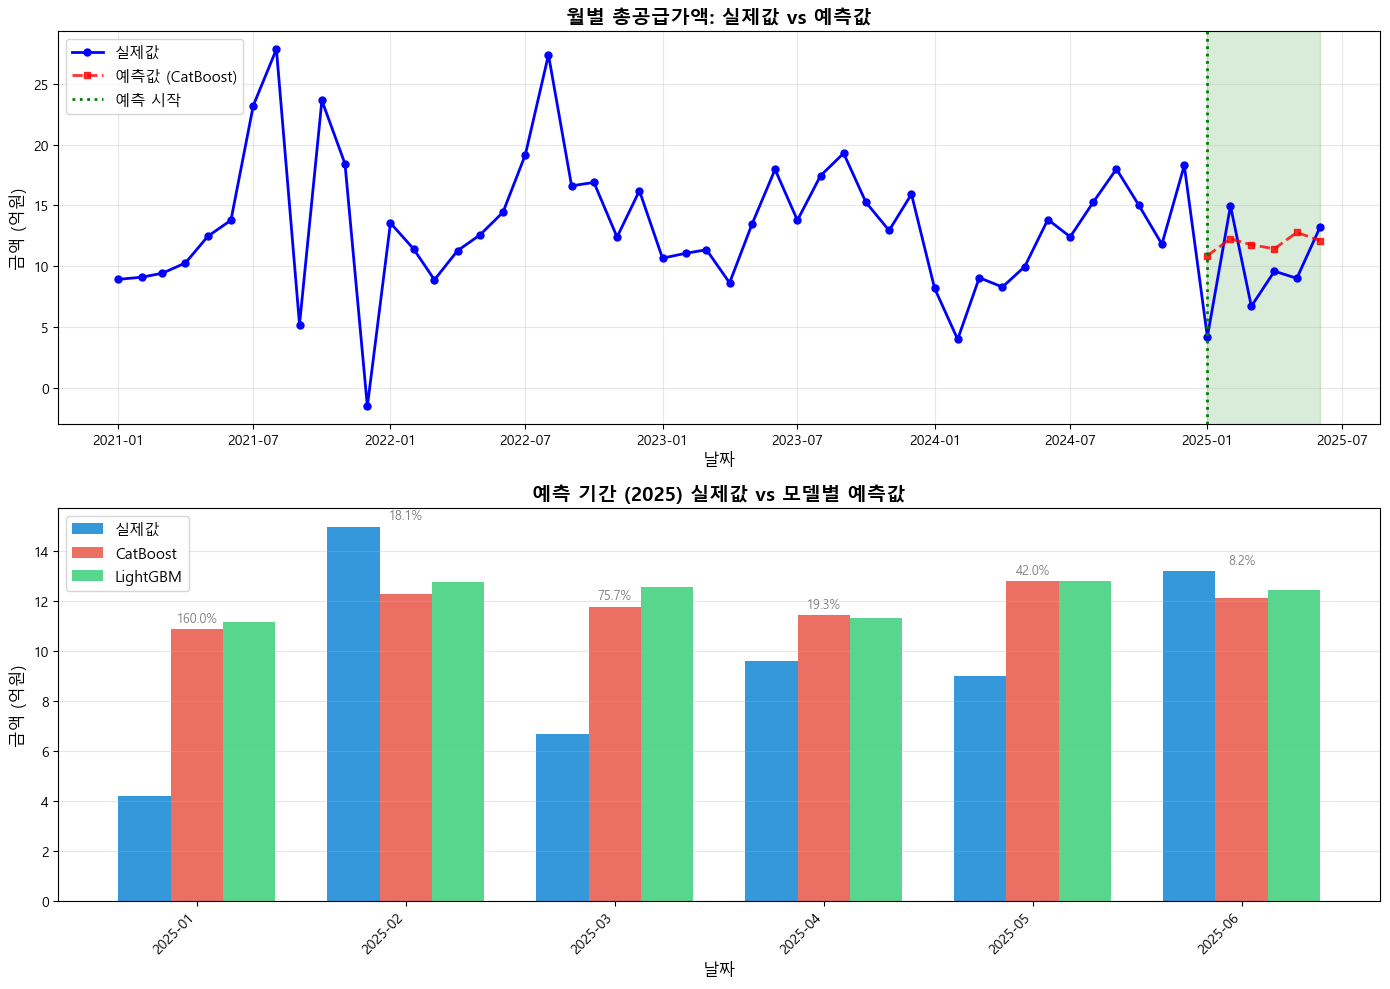


📊 예측 기간 상세 (CatBoost):
  2025-01: 실제=4.2억, 예측=10.9억, 오차=160.0%
  2025-02: 실제=15.0억, 예측=12.3억, 오차=18.1%
  2025-03: 실제=6.7억, 예측=11.8억, 오차=75.7%
  2025-04: 실제=9.6억, 예측=11.4억, 오차=19.3%
  2025-05: 실제=9.0억, 예측=12.8억, 오차=42.0%
  2025-06: 실제=13.2억, 예측=12.1억, 오차=8.2%


In [3]:
"""
📈 실제값 vs 예측값 시계열 비교
"""
from main_v2 import load_data, prepare_monthly_target, CONFIG_V2
import glob

# 데이터 로드
config = CONFIG_V2.copy()
data = load_data(config)
monthly = prepare_monthly_target(data, config)

# 예측 결과 로드
forecast_files = sorted(glob.glob('./result/forecast_all_*.csv'))
latest_forecast = forecast_files[-1]
df_pred = pd.read_csv(latest_forecast)
df_pred['date'] = pd.to_datetime(df_pred['DM_DATA'])

# 실제값과 병합
monthly['date'] = pd.to_datetime(monthly['date'])
df_plot = monthly[['date', 'TOT_MN_MNAM']].copy()
df_plot = df_plot.merge(df_pred[['date', 'CatBoost', 'LightGBM', 'XGBoost']], on='date', how='left')

print(f"데이터 기간: {df_plot['date'].min()} ~ {df_plot['date'].max()}")
print(f"총 {len(df_plot)}개월")

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. 전체 시계열
ax1 = axes[0]
ax1.plot(df_plot['date'], df_plot['TOT_MN_MNAM']/1e8, 'b-o', 
         label='실제값', linewidth=2, markersize=5)

# 예측값이 있는 구간만 플롯
pred_mask = df_plot['CatBoost'].notna()
ax1.plot(df_plot.loc[pred_mask, 'date'], df_plot.loc[pred_mask, 'CatBoost']/1e8, 
         'r--s', label='예측값 (CatBoost)', linewidth=2, markersize=5, alpha=0.8)

# 검증 기간 표시
valid_start = df_plot.loc[pred_mask, 'date'].min()
ax1.axvline(x=valid_start, color='green', linestyle=':', linewidth=2, label='예측 시작')
ax1.axvspan(valid_start, df_plot['date'].max(), alpha=0.15, color='green')

ax1.set_xlabel('날짜', fontsize=12)
ax1.set_ylabel('금액 (억원)', fontsize=12)
ax1.set_title('월별 총공급가액: 실제값 vs 예측값', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. 예측 기간 상세
ax2 = axes[1]
pred_df = df_plot[pred_mask].copy()

x = np.arange(len(pred_df))
width = 0.25

bars1 = ax2.bar(x - width, pred_df['TOT_MN_MNAM']/1e8, width, label='실제값', color='#3498db')
bars2 = ax2.bar(x, pred_df['CatBoost']/1e8, width, label='CatBoost', color='#e74c3c', alpha=0.8)
bars3 = ax2.bar(x + width, pred_df['LightGBM']/1e8, width, label='LightGBM', color='#2ecc71', alpha=0.8)

ax2.set_xlabel('날짜', fontsize=12)
ax2.set_ylabel('금액 (억원)', fontsize=12)
ax2.set_title('예측 기간 (2025) 실제값 vs 모델별 예측값', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([d.strftime('%Y-%m') for d in pred_df['date']], rotation=45, ha='right')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# 오차율 표시 (CatBoost)
for i, (idx, row) in enumerate(pred_df.iterrows()):
    if pd.notna(row['CatBoost']):
        error_pct = abs(row['TOT_MN_MNAM'] - row['CatBoost']) / row['TOT_MN_MNAM'] * 100
        ax2.text(i, max(row['TOT_MN_MNAM'], row['CatBoost'])/1e8 + 0.3, 
                f'{error_pct:.1f}%', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

# 상세 통계
print("\n📊 예측 기간 상세 (CatBoost):")
for _, row in pred_df.iterrows():
    actual = row['TOT_MN_MNAM']
    pred = row['CatBoost']
    error_pct = abs(actual - pred) / actual * 100
    print(f"  {row['date'].strftime('%Y-%m')}: 실제={actual/1e8:.1f}억, "
          f"예측={pred/1e8:.1f}억, 오차={error_pct:.1f}%")

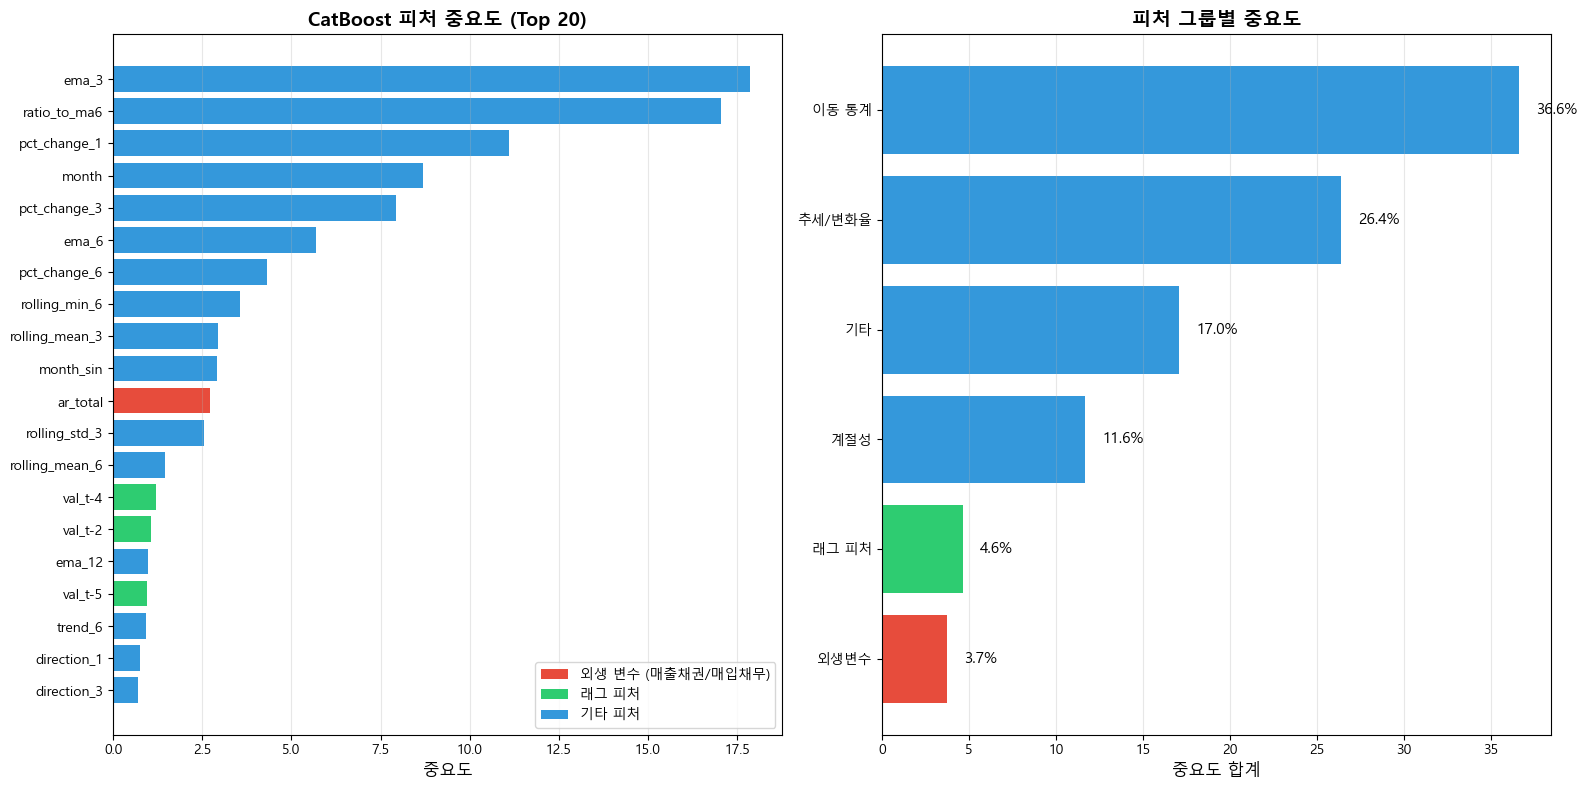


📊 피처 그룹별 중요도:
  이동 통계: 36.6%
  추세/변화율: 26.4%
  기타: 17.0%
  계절성: 11.6%
  래그 피처: 4.6%
  외생변수: 3.7%


In [4]:
"""
📊 피처 중요도 분석
"""
import joblib

# 저장된 모델 로드
checkpoint_path = './checkpoint/checkpoint_20260315_222412/'
models = joblib.load(checkpoint_path + 'all_models.pkl')

import json
with open(checkpoint_path + 'feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

# CatBoost 피처 중요도
catboost_model = models['CatBoost']
importance = catboost_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importance
}).sort_values('importance', ascending=True)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. CatBoost 피처 중요도 (상위 20개)
ax1 = axes[0]
top_20 = importance_df.tail(20)
colors = ['#e74c3c' if 'ex_' in f or 'ar_' in f or 'ap_' in f else 
          '#2ecc71' if 'val_t-' in f else '#3498db' for f in top_20['feature']]
ax1.barh(top_20['feature'], top_20['importance'], color=colors)
ax1.set_xlabel('중요도', fontsize=12)
ax1.set_title('CatBoost 피처 중요도 (Top 20)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 범례 추가
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='외생 변수 (매출채권/매입채무)'),
    Patch(facecolor='#2ecc71', label='래그 피처'),
    Patch(facecolor='#3498db', label='기타 피처')
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=10)

# 2. 피처 그룹별 중요도 합계
ax2 = axes[1]
importance_df['group'] = importance_df['feature'].apply(lambda x: 
    '외생변수' if ('ex_' in x or 'ar_' in x or 'ap_' in x or 'purchase' in x or 'revenue_purchase' in x) else
    '래그 피처' if 'val_t-' in x else
    '이동 통계' if 'rolling' in x or 'ema' in x else
    '계절성' if 'month' in x or 'quarter' in x else
    '추세/변화율' if 'trend' in x or 'pct' in x or 'direction' in x else
    '기타'
)

group_importance = importance_df.groupby('group')['importance'].sum().sort_values()
colors = ['#e74c3c' if g == '외생변수' else '#2ecc71' if g == '래그 피처' else '#3498db' 
          for g in group_importance.index]
ax2.barh(group_importance.index, group_importance.values, color=colors)
ax2.set_xlabel('중요도 합계', fontsize=12)
ax2.set_title('피처 그룹별 중요도', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# 비율 표시
total = group_importance.sum()
for i, (idx, v) in enumerate(group_importance.items()):
    ax2.text(v + total*0.01, i, f'{v/total*100:.1f}%', va='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\n📊 피처 그룹별 중요도:")
for group, imp in group_importance.sort_values(ascending=False).items():
    print(f"  {group}: {imp/total*100:.1f}%")

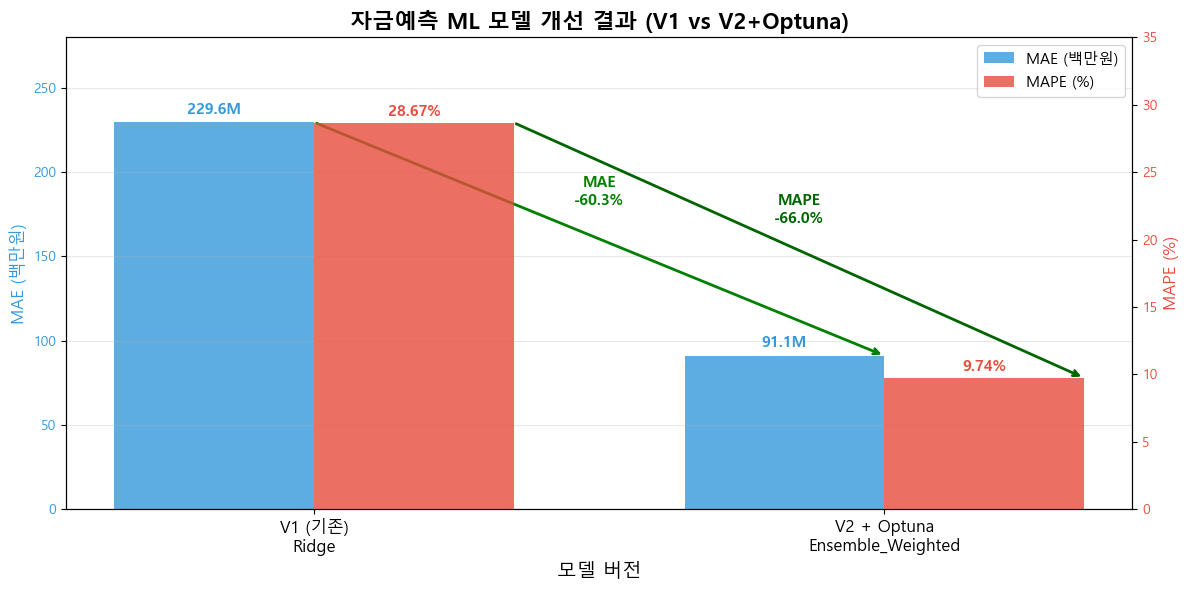

             자금예측 ML 모델 개선 최종 요약
  V1 Best (Ridge):           MAE=229.6M,  MAPE=28.67%
  V2+Optuna (Ensemble):      MAE=91.1M,   MAPE=9.74%
------------------------------------------------------------
  MAE  개선율: -60.3% (138.5M 감소)
  MAPE 개선율: -66.0% (18.93%p 감소)

💡 주요 개선 요소:
  1. 외생 변수 피처 (매출채권/매입채무 데이터)
  2. CatBoost, LightGBM 모델 추가
  3. Optuna 하이퍼파라미터 최적화
  4. 가중 앙상블 (Ensemble_Weighted)
  5. 고급 시계열 피처 (EMA, 추세, 변화율)


In [5]:
"""
🏆 V1 vs V2 최종 비교 요약
"""
fig, ax = plt.subplots(figsize=(12, 6))

# 데이터
versions = ['V1 (기존)\nRidge', 'V2 + Optuna\nEnsemble_Weighted']
mae_values = [229.6, 91.1]  # 백만원 단위
mape_values = [28.67, 9.74]

x = np.arange(len(versions))
width = 0.35

# 이중 y축
ax2_twin = ax.twinx()

# 막대 그래프
bars1 = ax.bar(x - width/2, mae_values, width, label='MAE (백만원)', color='#3498db', alpha=0.8)
bars2 = ax2_twin.bar(x + width/2, mape_values, width, label='MAPE (%)', color='#e74c3c', alpha=0.8)

# 축 설정
ax.set_xlabel('모델 버전', fontsize=14)
ax.set_ylabel('MAE (백만원)', fontsize=12, color='#3498db')
ax2_twin.set_ylabel('MAPE (%)', fontsize=12, color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(versions, fontsize=12)
ax.tick_params(axis='y', labelcolor='#3498db')
ax2_twin.tick_params(axis='y', labelcolor='#e74c3c')

# 값 표시
for bar, val in zip(bars1, mae_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            f'{val:.1f}M', ha='center', fontsize=11, fontweight='bold', color='#3498db')

for bar, val in zip(bars2, mape_values):
    ax2_twin.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                  f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold', color='#e74c3c')

# 개선율 화살표
ax.annotate('', xy=(1, mae_values[1]), xytext=(0, mae_values[0]),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(0.5, (mae_values[0] + mae_values[1])/2 + 20, 
        f'MAE\n-60.3%', ha='center', fontsize=11, color='green', fontweight='bold')

ax2_twin.annotate('', xy=(1.35, mape_values[1]), xytext=(0.35, mape_values[0]),
                  arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))
ax2_twin.text(0.85, (mape_values[0] + mape_values[1])/2 + 2, 
              f'MAPE\n-66.0%', ha='center', fontsize=11, color='darkgreen', fontweight='bold')

ax.set_title('자금예측 ML 모델 개선 결과 (V1 vs V2+Optuna)', fontsize=16, fontweight='bold')

# 범례
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)

ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 280)
ax2_twin.set_ylim(0, 35)

plt.tight_layout()
plt.show()

print("=" * 60)
print("             자금예측 ML 모델 개선 최종 요약")
print("=" * 60)
print(f"  V1 Best (Ridge):           MAE=229.6M,  MAPE=28.67%")
print(f"  V2+Optuna (Ensemble):      MAE=91.1M,   MAPE=9.74%")
print("-" * 60)
print(f"  MAE  개선율: -60.3% ({229.6-91.1:.1f}M 감소)")
print(f"  MAPE 개선율: -66.0% ({28.67-9.74:.2f}%p 감소)")
print("=" * 60)
print("\n💡 주요 개선 요소:")
print("  1. 외생 변수 피처 (매출채권/매입채무 데이터)")
print("  2. CatBoost, LightGBM 모델 추가")
print("  3. Optuna 하이퍼파라미터 최적화")
print("  4. 가중 앙상블 (Ensemble_Weighted)")
print("  5. 고급 시계열 피처 (EMA, 추세, 변화율)")